# Images for 3 Layer Guide

This notebook creates images associated with the input fields and resultant fields for the 3 layer slab waveguide.  These images are used in documentary materials for the repo and visualizations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from slab import SlabExact, plot_complex
from IPython.display import Video, Image
from scipy.integrate import quad
from scipy.optimize import newton
from matplotlib.transforms import Bbox

%matplotlib widget
plt.style.use('dark_background')
# plt.style.available

In [2]:
A = SlabExact(symmetric=True, Ts=[3,2,3])

## Input fields

In [3]:
w = .5
s = 0
amp = .6

Lx = -w + s
Rx = w + s

def quadratic_piecewise(x):
    conds = [(x<Lx), ((Lx<=x)*(x<=Rx)), (x>Rx)]
    funcs = [0, lambda x: amp * (1 - ((x-s)/w)**2), 0]
    return np.piecewise(x, conds, funcs)

def quadratic_piecewise2d(x, zs=None, wavenumber=A.K0):
    conds = [(x<Lx), ((Lx<=x)*(x<=Rx)), (x>Rx)]
    funcs = [0, lambda x: amp * (1 - ((x-s)/w)**2), 0]
    fx = np.piecewise(x, conds, funcs)
    fz = np.exp(1j * wavenumber * zs)
    return np.outer(fz, fx)

f0 = quadratic_piecewise

### Create Input field and RIP image for web use

Need these as thumbnails for clicking to link to visualizations on website.

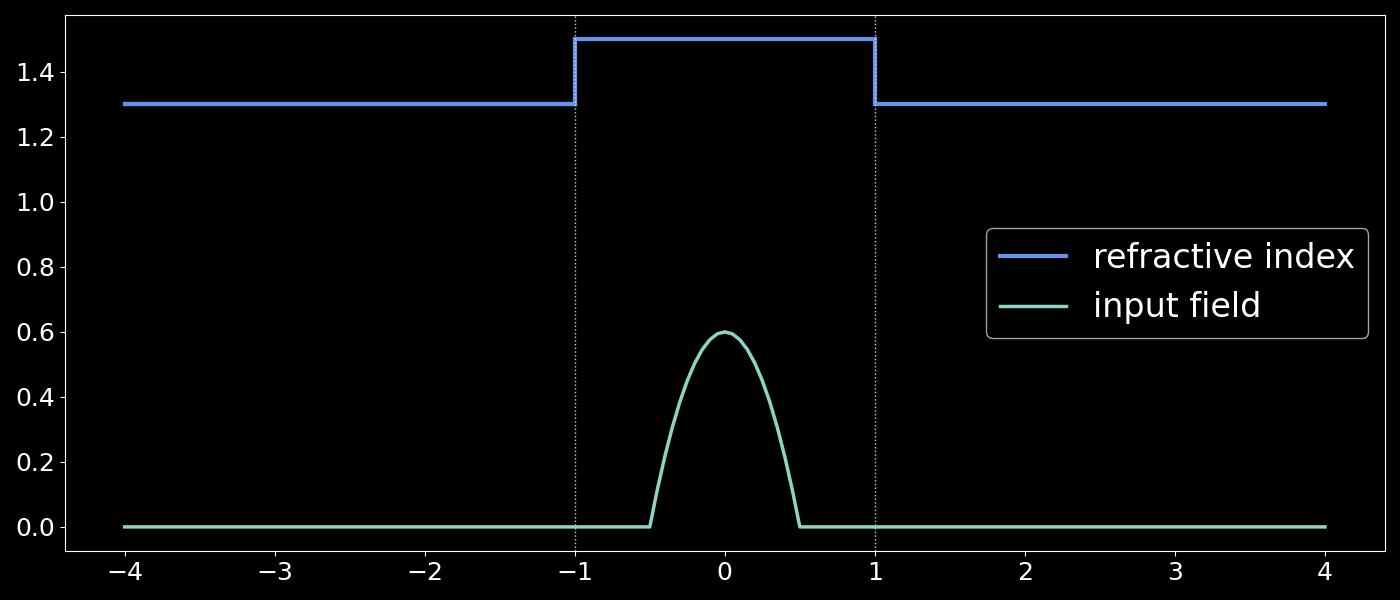

In [4]:
plt.close('all')
with plt.style.context('seaborn-v0_8-dark-palette'):
    fig, ax = A.plot_refractive_index(part='real', label='refractive index',
                                      figsize=(14,6), lw=3);
    A.add_1d_plot(f0, label='input field', color='C0', lw=2.5, legend_fontsize=24);
    # ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=18)
    ax.tick_params(axis='x', labelsize=18)
    fig.tight_layout();

In [5]:
# fig.savefig('/home/pv/local/website/images/basic_slab_RIP_and_input_dark.png', dpi=300)
# fig.savefig('/home/pv/local/slab/images/basic_slab_RIP_and_input_dark.png', dpi=300)

# 3D version

## Planes in 3D for slab waveguide face

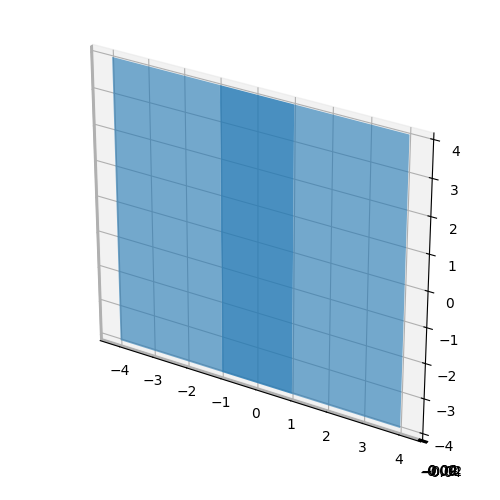

In [4]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


width_center = 2
width_outer = 3
height = 8
center1 = np.array([0, 0, 0])

dir1 = np.array([1, 0, 0])
dir2 = np.array([0, 0, 1])
dir3 = np.array([0, 1, 0])

def rect_verts(width, height, center=center1, dir1=dir1, dir2=dir2):
    return (center + np.array([dir1 * width / 2 - dir2 * height / 2,
                              dir1 * width / 2 + dir2 * height / 2,
                              -dir1 * width / 2 + dir2 * height / 2,
                              -dir1 * width / 2 - dir2 * height / 2]))[np.newaxis]

# Coordinates of rectangle
verts_center = rect_verts(width_center, height)
verts_right = rect_verts(width_outer, height, center1 + (width_center + width_outer)/2 * dir1)
verts_left = rect_verts(width_outer, height, center1 - (width_center + width_outer)/2 * dir1)
    
plt.close('all')
with plt.style.context('default'):
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot((0,0,1,1), projection='3d')
    
    poly_center = Poly3DCollection(verts_center, alpha=.8)
    poly_right = Poly3DCollection(verts_right, alpha=.6)
    poly_left = Poly3DCollection(verts_left, alpha=.6)
    ax.add_collection3d(poly_center)
    ax.add_collection3d(poly_right)
    ax.add_collection3d(poly_left)
    fig.set_facecolor('green')
    # fig.tight_layout()
    ax.set_aspect('equal')
    
    plt.show()

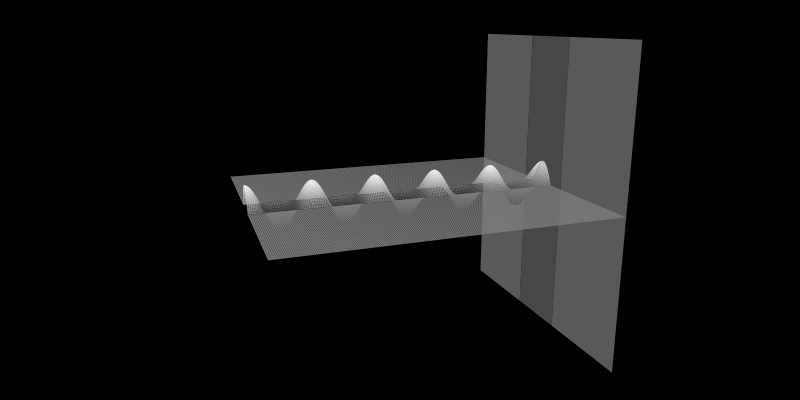

In [56]:
plt.close('all')

xs = np.concatenate([np.linspace(-4, Lx, 2), np.linspace(Lx, Rx, 30)[1:], np.linspace(Rx, 4, 2)[1:]])
# xs = np.linspace(Lx, Rx, 30)
with plt.style.context('dark_background'):
    Fx = lambda x, y: quadratic_piecewise2d(x, y)
    fig, ax = A.plot_field_2d_surface(Fx, xs=xs,
                                      zmin=-9, zmax=0, zref=200, 
                                      z_lim_factor=1,
                                      cstride=1, rstride=1,
                                      # cmap=None,
                                      figsize=(8,4),
                                      cmap='gist_grey', show_axis=False,
                                      elev=15, azim=-20, roll=0,
                                      zoom=2, alpha=.9)
    # fig.set_facecolor('red')
    # ax.set_aspect('equal')
    # ax.set_axis_on()
    ax.set_proj_type('persp', focal_length=0.3)
    poly_center = Poly3DCollection(verts_center, color='.4', alpha=.7, lw=0, clip_on=False)
    poly_right = Poly3DCollection(verts_right, color='.5', alpha=.7, lw=0, clip_on=False)
    poly_left = Poly3DCollection(verts_left, color='.5', alpha=.7, lw=0, clip_on=False)
    ax.add_collection3d(poly_center)
    ax.add_collection3d(poly_right)
    ax.add_collection3d(poly_left)
    ax.set_box_aspect((8,9,8), zoom=1.4)
    # fig.tight_layout();


In [57]:
fig.bbox_inches

Bbox([[0.0, 0.0], [8.0, 4.0]])

In [58]:
box = Bbox([[1.5, 0], [8, 4]])

In [59]:
fig.savefig('test.png', dpi=288, bbox_inches=box)

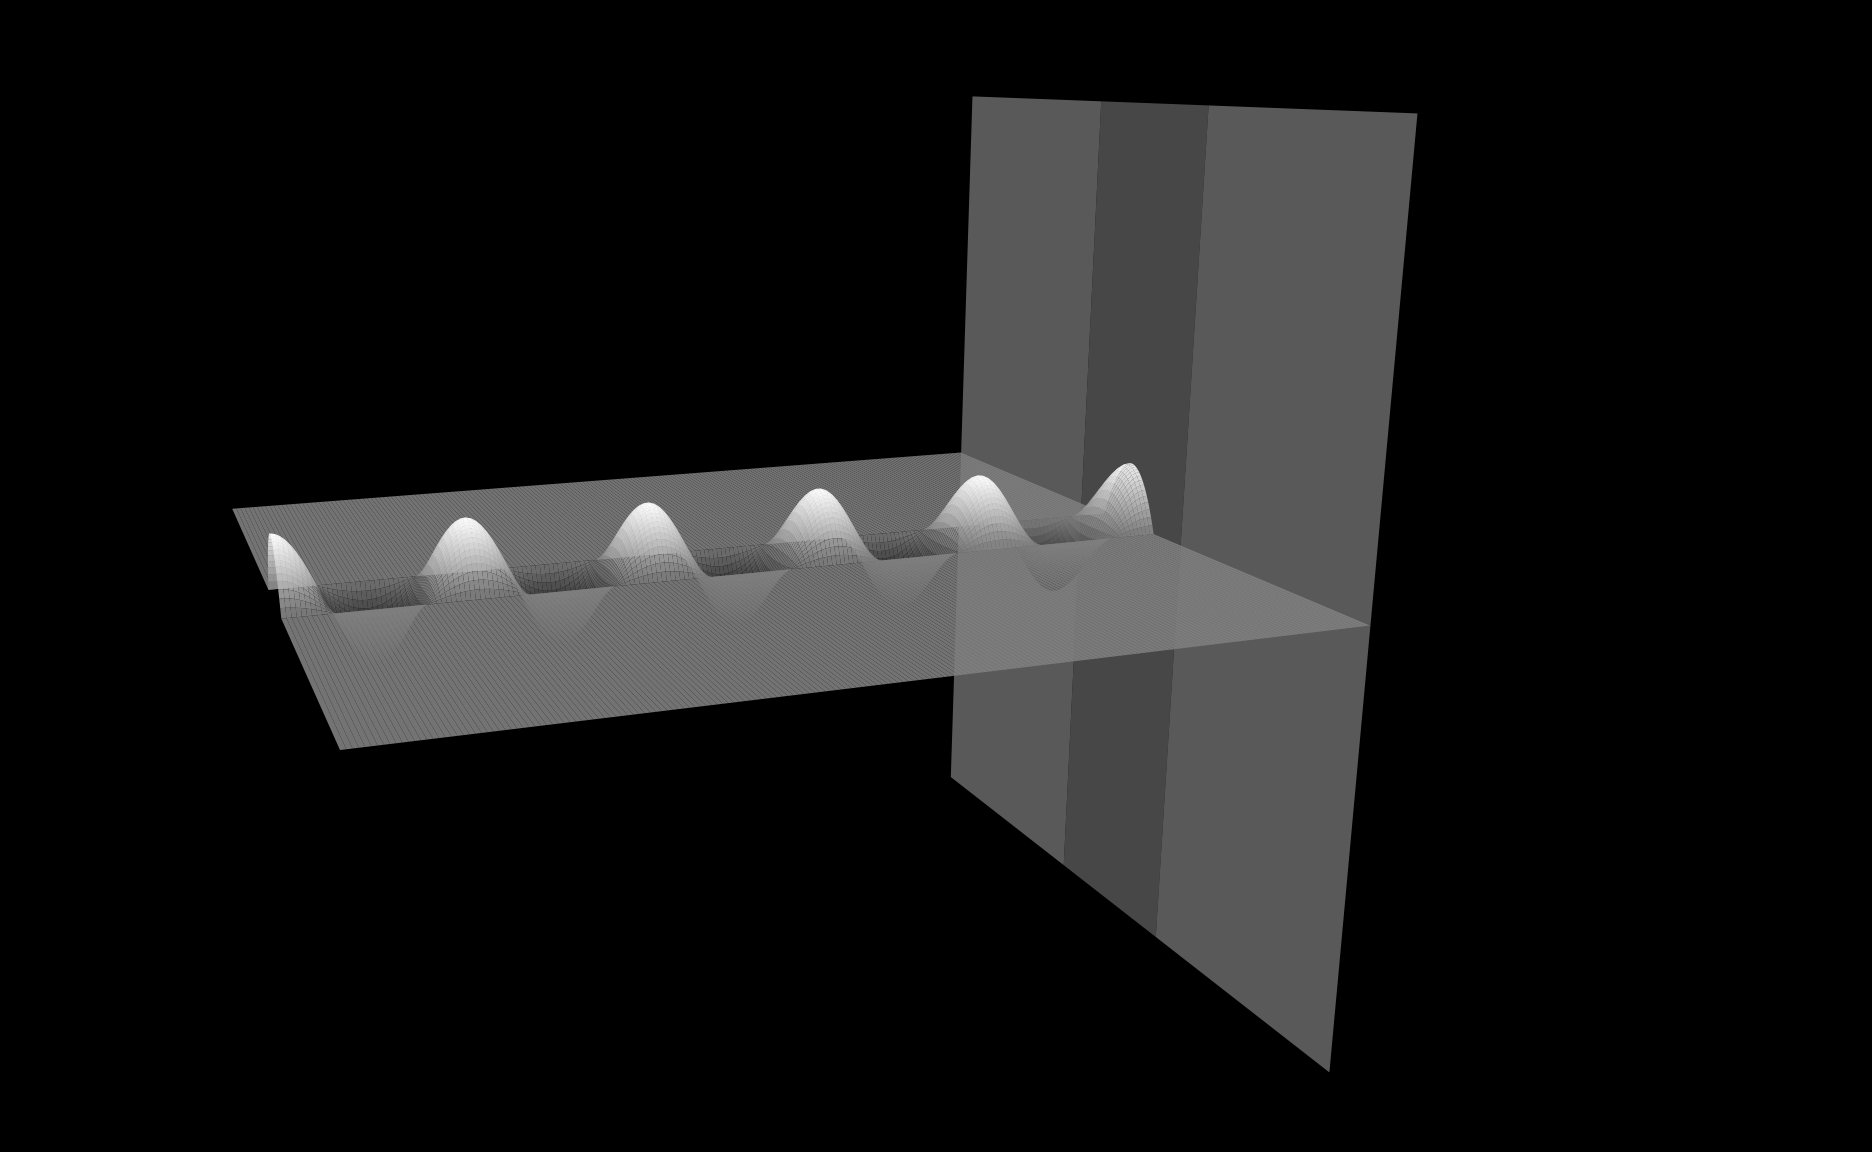

In [60]:
Image('test.png')

In [61]:
# fig.savefig('/home/pv/local/website/images/3d_input_field.png', transparent=True, dpi=290)

In [62]:
fig.savefig('/home/pv/local/slab/images/3d_input_field.png', transparent=True, dpi=288, bbox_inches=box)

# Resultant field images

## Determine fields

### Guided

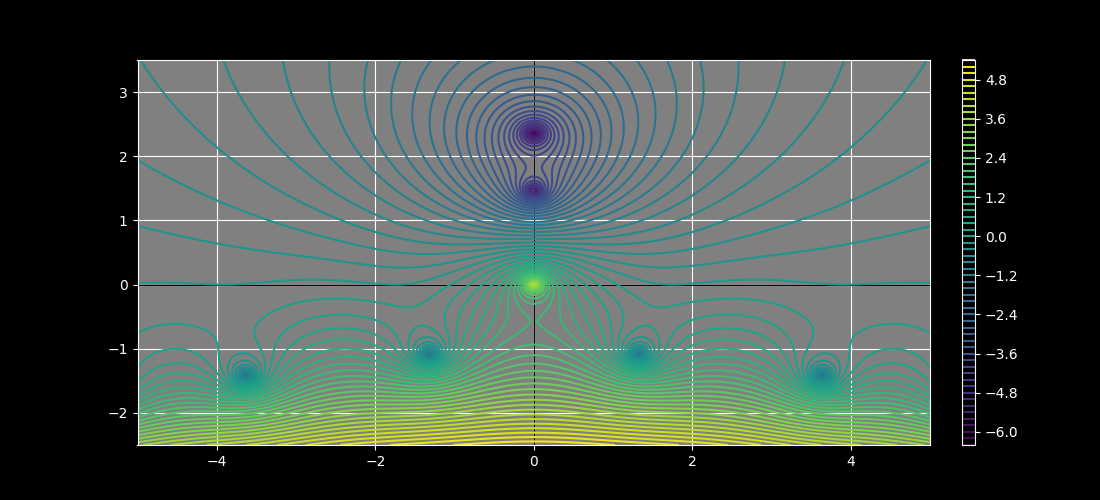

In [33]:
A.determinant_plot(-5, 5, -2.5, 3.5);

In [34]:
guesses = [2.5j, 1.48j]
Zs = np.array([newton(A.determinant, np.array(guess)) for guess in guesses])
A.plot_points(Zs)

In [35]:
Fs = [A.fields(Z, mode_type='guided', Normalizer='eigvec') for Z in Zs]
num = np.array([quad(lambda x: f0(x) * F(x), Lx, Rx, complex_func=True)[0] for F in Fs])
denom = np.array([quad(lambda x: np.abs(F(x))**2, -10, 10, complex_func=True)[0] for F in Fs])
coeffs = num / denom
coeffs

array([0.32468265+0.j, 0.        +0.j])

In [36]:
x0 = 0
z0 = 0
Guided = lambda x, z: sum([alpha * F(x, z) for (alpha, F) in zip(coeffs, Fs)])

### Radiation

In [37]:
Propagator = A.propagator()

In [38]:
P1_e = Propagator(A.real_contour(.0000001, A.Z_evanescent, 200), f0=f0, Lx=Lx, Rx=Rx, )
# P1_o = Propagator(A.real_contour(.000001, A.Z_evanescent, 700), f0=f0, Lx=Lx, Rx=Rx, sign=-1)

P2_e = Propagator(A.real_contour(A.Z_evanescent, 50, 300), f0=f0, Lx=Lx, Rx=Rx)
# P2_o = Propagator(A.real_contour(A.Z_evanescent, 50, 600), f0=f0, Lx=Lx, Rx=Rx, sign=-1)

(<Figure size 1100x400 with 1 Axes>, <Axes: >)

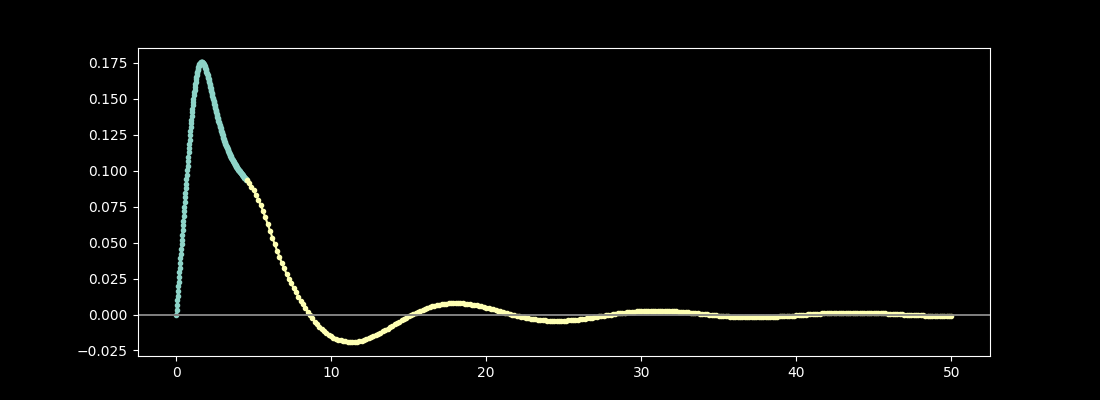

In [39]:
P1_e.plot_transform()
# P1_o.plot_transform(ax=plt.gca())
P2_e.plot_transform(ax=plt.gca())
# P2_o.plot_transform(ax=plt.gca())


In [40]:
P_prop = [
    P1_e,
    # P1_o,
]

P_ev = [
    P2_e,
    # P2_o
]


In [41]:
Prop = lambda x, z: sum([P.propagate(x,z) for P in P_prop])
Ev =  lambda x, z: sum([P.propagate(x,z) for P in P_ev])
Rad = lambda x, z: Prop(x, z) + Ev(x, z)

Full = lambda x, z: Rad(x, z) + Guided(x, z)
Diff = lambda x, z: f0(x) - Full(x,z)


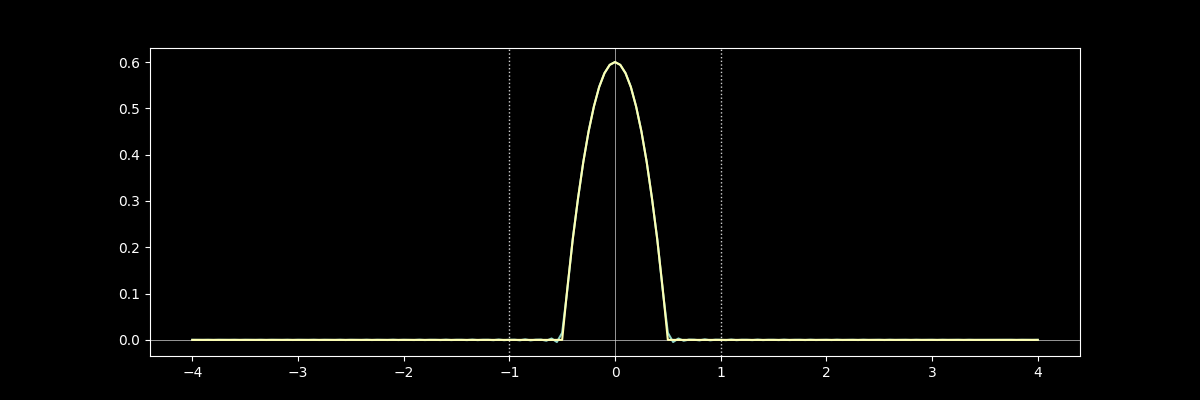

In [43]:
A.plot_field_1d(Full, figsize=(12,4), part='real')
A.add_1d_plot(f0)

In [181]:
# A.plot_field_2d(Full, xs=np.linspace(-20,20,200), colorbar=False, figsize=(10,8),
#                 zmax=24, zref=200);

## Images

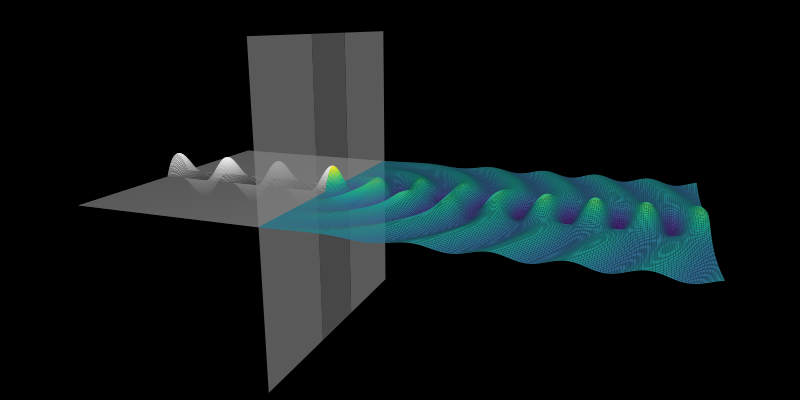

In [68]:
fig, ax = A.plot_field_2d_surface(Full, xs=np.linspace(-4, 4, 100), zs=np.linspace(0, 10, 200),
                                  cstride=1, rstride=1,
                                  elev=15, azim=20, roll=0,
                                  cmap='viridis', figsize=(8,4), zoom=1,
                                 );
A.add_2d_plot_surface(Fx, ax = ax, xs=xs, zmin=-5.5, zmax=0, zref=150, cmap='gray',
                     cstride=1, rstride=1);
poly_center = Poly3DCollection(verts_center, color='.4', alpha=.7, lw=0, clip_on=False)
poly_right = Poly3DCollection(verts_right, color='.5', alpha=.7, lw=0, clip_on=False)
poly_left = Poly3DCollection(verts_left, color='.5', alpha=.7, lw=0, clip_on=False)
ax.add_collection3d(poly_center)
ax.add_collection3d(poly_right)
ax.add_collection3d(poly_left);
ax.set_box_aspect((8, 15.5, 8), zoom=1.9)
# ax.set_aspect('equal')
ax.set_proj_type('persp', focal_length=0.3)



In [67]:
fig.bbox_inches

Bbox([[0.0, 0.0], [8.0, 4.0]])

In [69]:
box2 = Bbox([[.75, 0], [7.25, 4]])

In [70]:
fig.savefig('test.png', dpi=288, bbox_inches=box2)

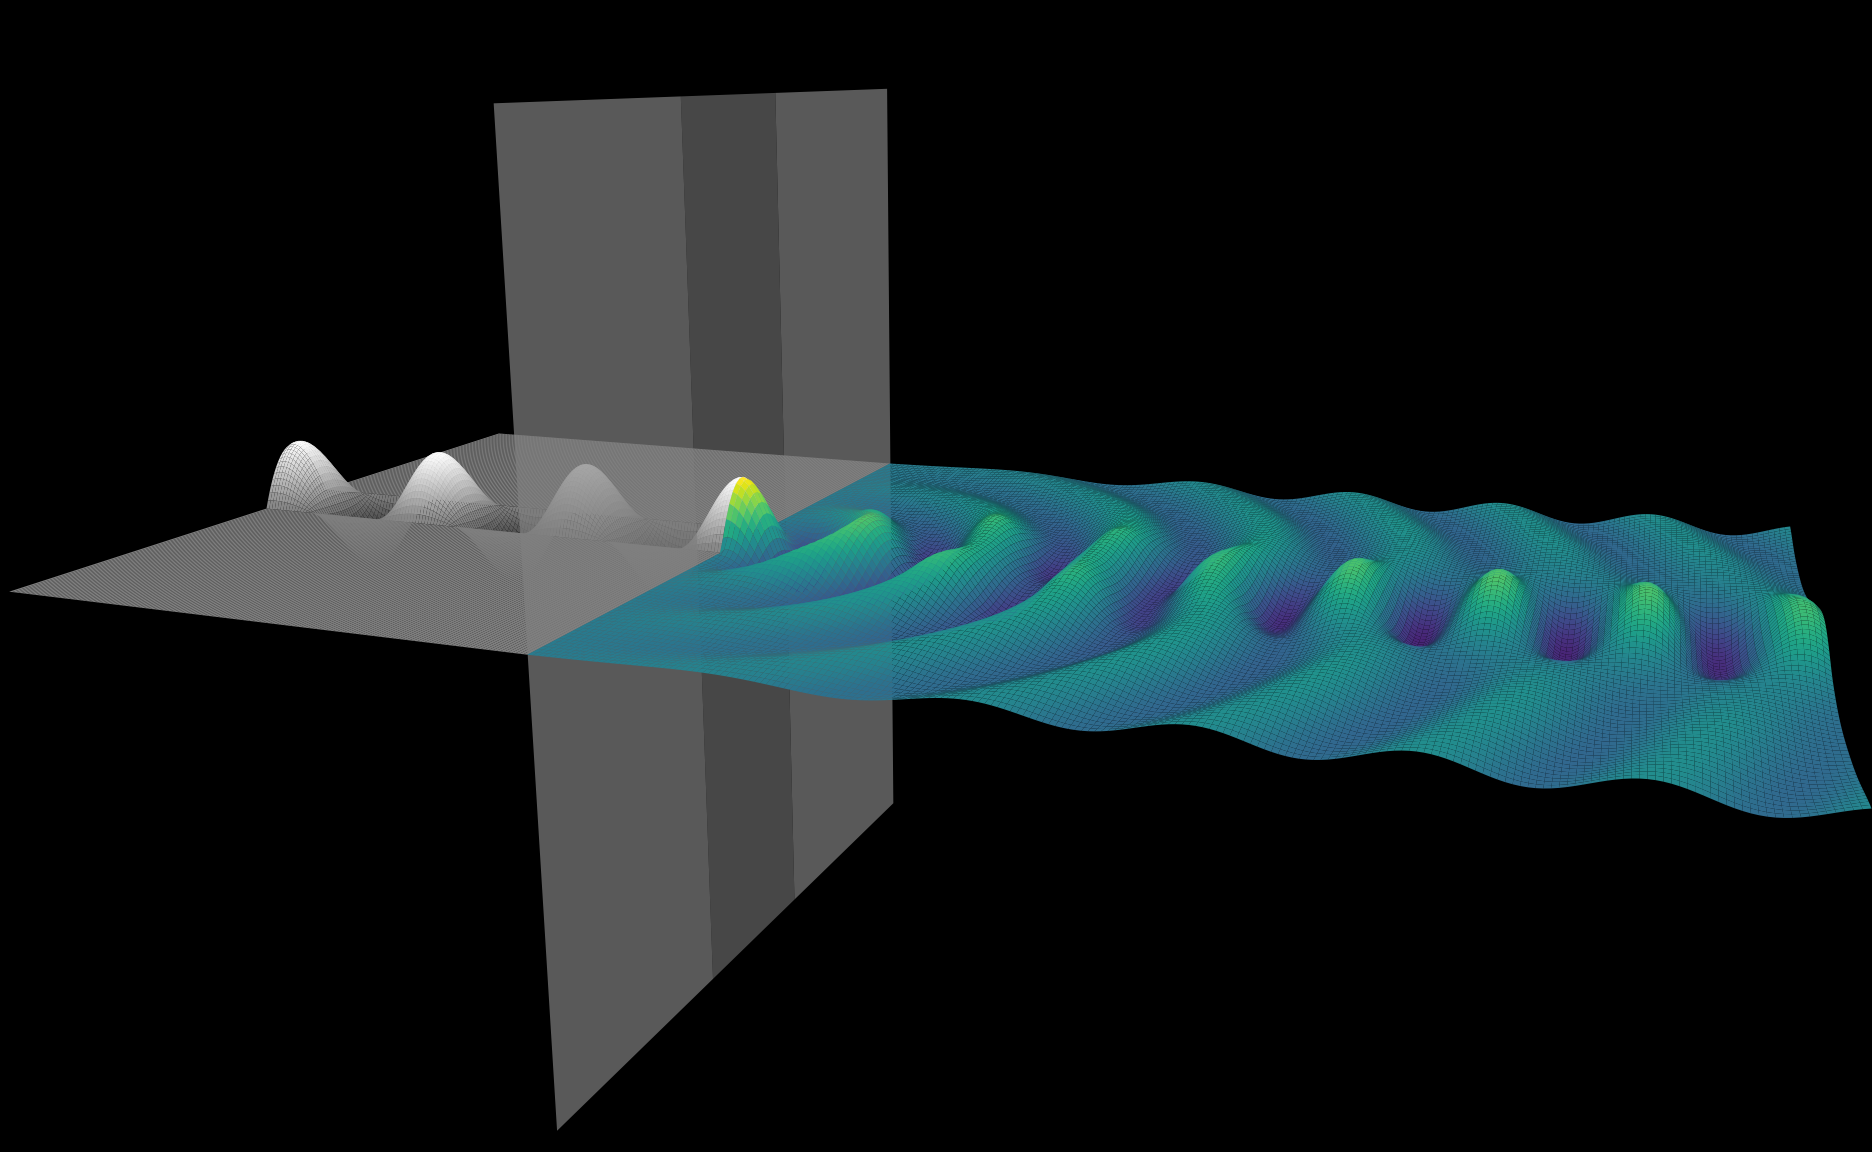

In [71]:
Image('test.png')

In [72]:
fig.savefig('/home/pv/local/slab/images/3d_resultant_field.png', transparent=True, dpi=288, bbox_inches=box2)

## Asymptotics in direction of propagation

(<Figure size 1200x500 with 1 Axes>, <Axes: >)

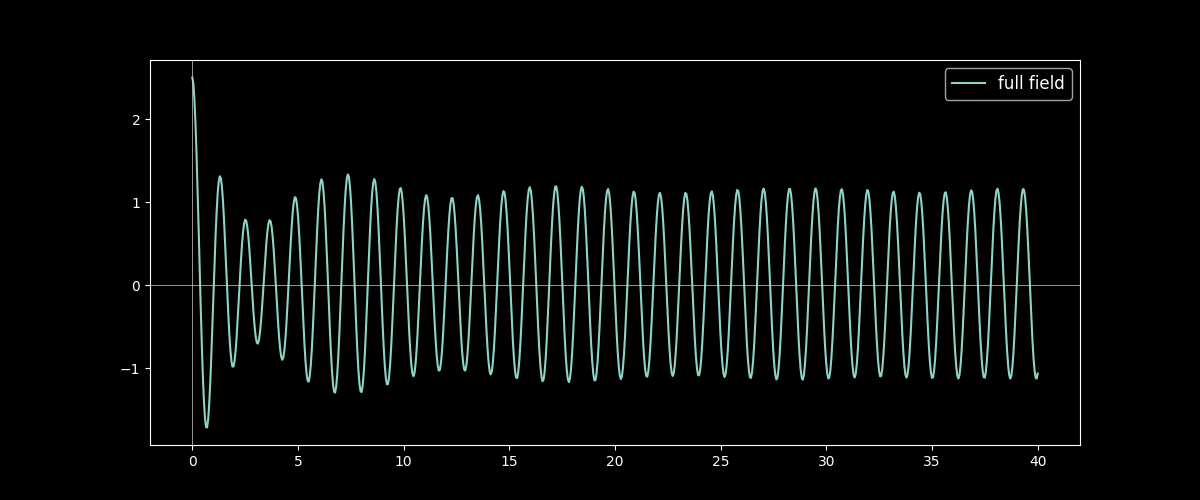

In [73]:
A.plot_field_1d(Full, zs=np.linspace(0, 40, 800), plot_Rhos=False, label='full field')

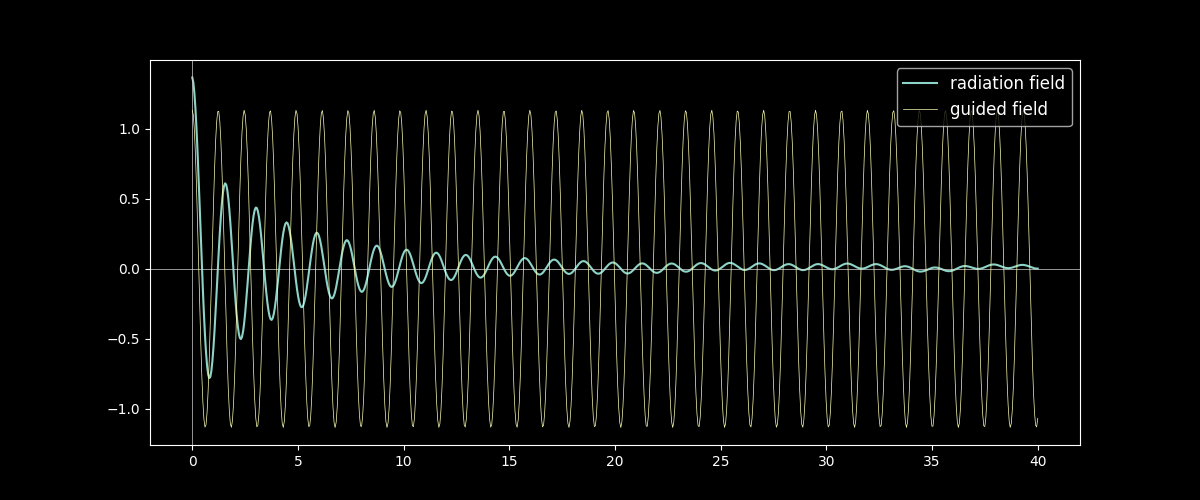

In [77]:
fig, ax = A.plot_field_1d(Rad, zs=np.linspace(0, 40, 800), plot_Rhos=False, label='radiation field')
A.add_1d_plot(Guided, zs=np.linspace(0, 40, 800), lw=.5, label='guided field')
